In [1]:
import sys


In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [5]:
from sklearn.datasets import make_blobs

In [6]:
import imblearn.over_sampling

In [7]:
for item in dir(imblearn.over_sampling):
    if 'SMO' in item:
        print(item)

BorderlineSMOTE
KMeansSMOTE
SMOTE
SMOTEN
SMOTENC
SVMSMOTE


In [8]:
from imblearn.over_sampling import SMOTE

In [ ]:
blobs_random_seed = 42
centers = [(0,0), (5,5)] #dictates the numver of clusters. in this case 2 clusters since we have 2 centers
cluster_std = 1.5
num_features = 2
num_samples_total = 1600

In [21]:
X, y = make_blobs(
    n_samples=num_samples_total,
    n_features=num_features,
    centers=centers,
    cluster_std=cluster_std,
    random_state=0,
)

X, y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [22]:
X.shape, y.shape

((1600, 2), (1600,))

In [23]:
# In here we have set y==1 as the class we are downsampling against
#Theerefore, y==0 would be our majority class
data1 = X[y==0] 
data2 = X[y==1].sample(200, random_state=0)

In [25]:
data1.shape, data2.shape

((800, 2), (200, 2))

In [ ]:
#Axis = 0, we are stacking this vertically. Appending the undersampled data2 to data1
X = pd.concat([data1, data2], axis=0)
X.shape

(1000, 2)

In [27]:
X.head()

,varA,varB
0,-3.9888,0.9095
2,1.1279,0.8445
3,-2.4486,-0.1007
4,-1.0936,0.2948
5,0.2990,-0.0759


In [28]:
X.tail()

,varA,varB
1308,4.8952,5.3752
1063,3.3467,4.9632
736,3.3385,5.3525
41,6.0973,5.4795
637,4.3562,7.0628


In [29]:
X.shape, y.shape

((1000, 2), (1600,))

In [32]:
y = y.loc[X.index]
X.shape, y.shape

((1000, 2), (1000,))

<Axes: xlabel='varA', ylabel='varB'>

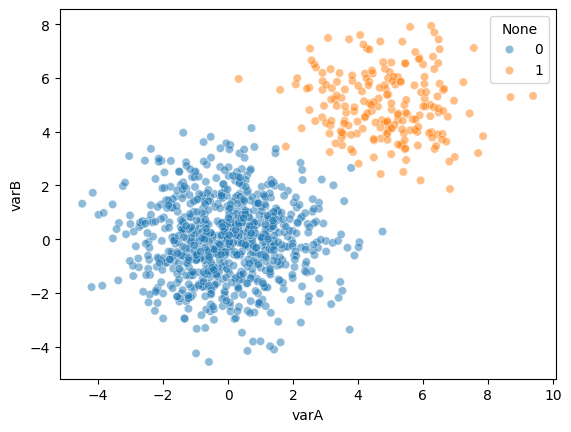

In [33]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)

# SMOTE

In [34]:
from imblearn.over_sampling import SMOTE

In [ ]:
#From the look of it, the resampling will be performed on the minority class and automatically matching it to the number of the majority class
#I would assume the normal setup would simply try to reach a balancing ratio of 1
sm =  SMOTE(sampling_strategy='auto', random_state=0, k_neighbors=5)

X_res, y_res = sm.fit_resample(X,y)

In [35]:
?SMOTE

Init signature: SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5)
Docstring:     
Class to perform over-sampling using SMOTE.

This object is an implementation of SMOTE - Synthetic Minority
Over-sampling Technique as presented in [1]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only available for **binary** classification. An
           error is raised for 

In [37]:
X.shape, X_res.shape

((1000, 2), (1600, 2))

In [38]:
y.value_counts(), y_res.value_counts()

(0    800
 1    200
 Name: count, dtype: int64,
 0    800
 1    800
 Name: count, dtype: int64)

In [40]:
for item in dir(my_functions):
    if 'Scatter' in item:
        print(item)

Scatterplot


In [41]:
from my_functions import Scatterplot

In [42]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

>>>Scatterplot(X, y, X_resampled, y_resampled)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

In [48]:
def Scatterplot(data1, class1, data2, class2):
    '''
    Plot 2 Scatterplots.
    1 Row and 2 columns, given the 2 provided datasets
    Ex:

    >>>Scatterplot(X, y, X_resampled, y_resampled)


    '''
    
    plt.figure(figsize=(15,8))
    plt.subplot(121)
    sns.scatterplot(data=data1, x=data1.columns[0], y=data1.columns[1], alpha=0.5, hue=class1)

    plt.subplot(122)
    sns.scatterplot(data=data2, x=data2.columns[0], y=data2.columns[1], alpha=0.5, hue=class2)

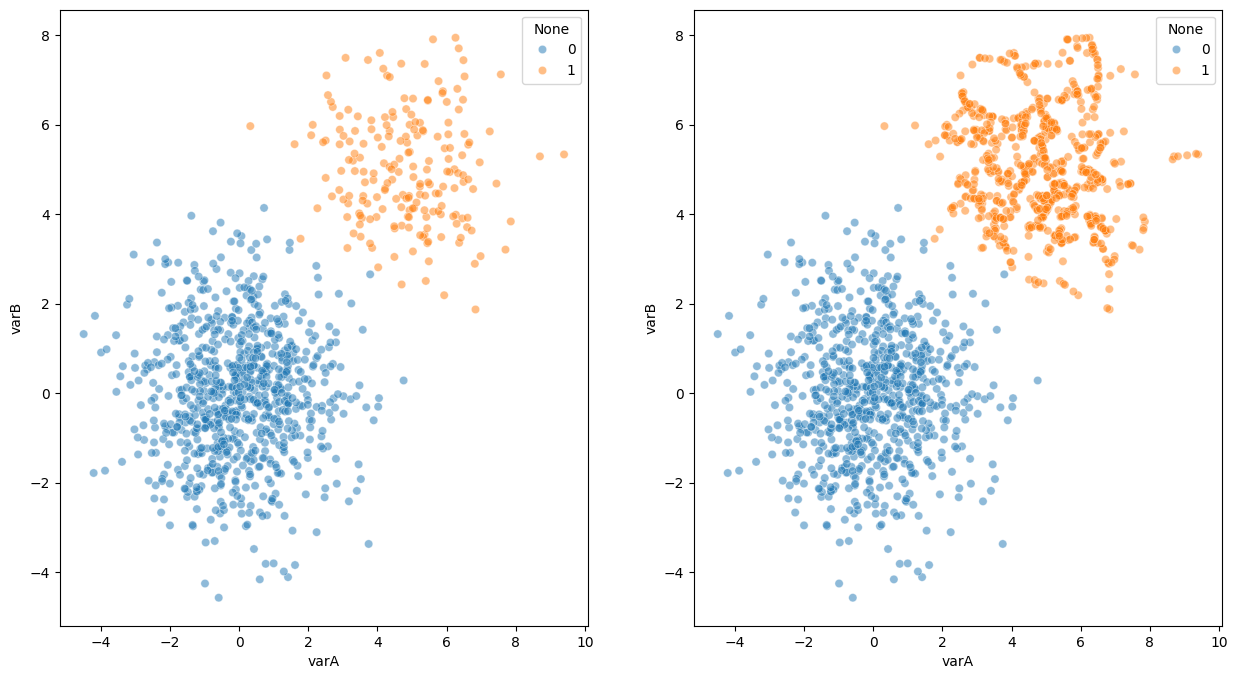

In [ ]:
'''
Notice how the distribution seems to be filling the space betwee points..
The overall structure remains the same.
This is because the SMOTE works by interpolating between the distance between the KNN data points

'''

Scatterplot(X, y, X_res, y_res)